In [430]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12.5})
from scipy.fft import fft, ifft
import time

$X[k] = \sum_{n=0}^{N-1} x[n]e^{-i2\pi \frac{k}{N}n}$ - the DFT

$x[n] = \frac{1}{N}\sum_{k=0}^{N-1} X_{k}e^{\frac{i2\pi kn}{N}}$ - the inverse DFT

where
* N is the number of samples.
* n is the current sample (index). 
* k is the current frequency (index).
* x[n] is the signal’s value at n.
* X[k] is the DFT at n.

# Q1 b

In [267]:
def func(x):
    return np.exp(-50*(x-0.5)**2)

def func_analytic(k):
    return np.sqrt(np.pi/50)*np.exp(-0.5*1j*k-(k**2/200))

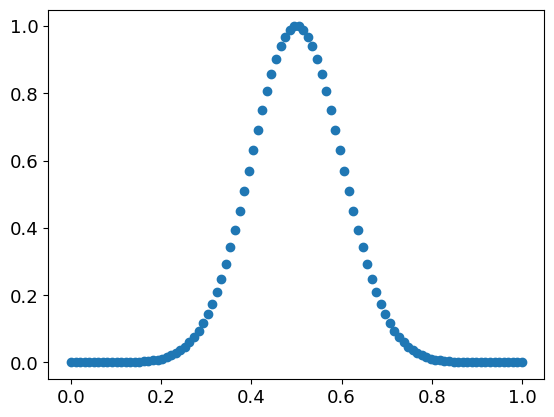

In [426]:
x = np.linspace(0,1,100)
plt.scatter(x,func(x))

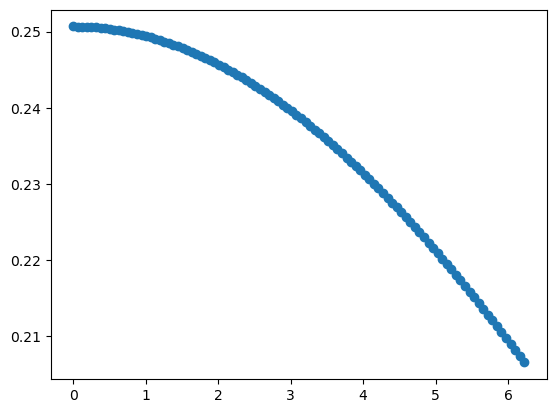

In [416]:
N=100
k = 2*np.pi * np.arange(N)/N
plt.scatter(k,np.abs(func_analytic(k)))

Part b is saying to do the forward DFT for three values of N on the equation that I did analytically, then plot the results of these next to my analytical fourier transform.

When it says to invert k-space results, it means to do the inverse fourier transform.

In [446]:
def func_sampled(N):
    x = np.arange(N)/N #need to discretize the function
    
    return np.exp(-50*(x - 0.5)**2)

def DFT(inputfunc,N):
    X=np.zeros(N,dtype="complex") #keep the complex parts too
    for k in range(0,N): #by nature of python this should be N-1
        for n in range(0,N):
            X[k] += inputfunc[n]*(np.exp((-1j*2*np.pi*n*k)/N))
    return X

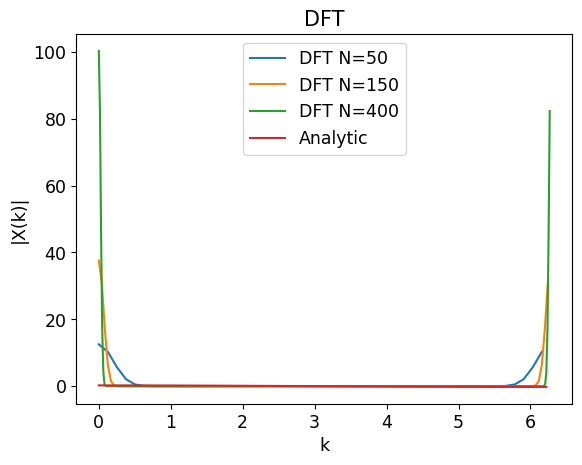

In [461]:
for N in [50, 150, 400]:
    fx = func_sampled(N)
    X = DFT(fx, N)
    k = 2*np.pi * np.arange(N)/N
    plt.plot(k, np.abs(X), label=f"DFT N={N}")

N=100
k_a = 2*np.pi * np.arange(N)/N
plt.plot(k_a,func_analytic(k_a),label="Analytic")

plt.xlabel("k")
plt.ylabel("|X(k)|")
plt.legend()
plt.title("DFT")
plt.savefig("DFT.png",dpi=300)
plt.show()

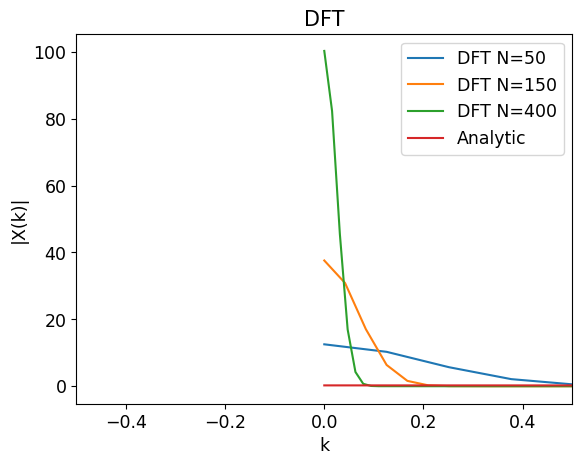

In [462]:
for N in [50, 150, 400]:
    fx = func_sampled(N)
    X = DFT(fx, N)
    k = 2*np.pi * np.arange(N)/N
    plt.plot(k, np.abs(X), label=f"DFT N={N}")

N=100
k_a = 2*np.pi * np.arange(N)/N
plt.plot(k_a,func_analytic(k_a),label="Analytic")

plt.xlim(-.5,.5)
plt.xlabel("k")
plt.ylabel("|X(k)|")
plt.legend()
plt.title("DFT")
plt.savefig("DFT_zoom.png",dpi=300)
plt.show()

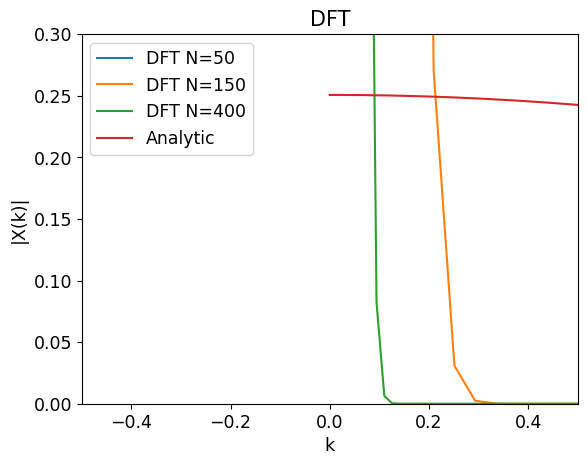

In [463]:
for N in [50, 150, 400]:
    fx = func_sampled(N)
    X = DFT(fx, N)
    k = 2*np.pi * np.arange(N)/N
    plt.plot(k, np.abs(X), label=f"DFT N={N}")

N=100
k_a = 2*np.pi * np.arange(N)/N
plt.plot(k_a,func_analytic(k_a),label="Analytic")

plt.xlim(-.5,.5)
plt.ylim(0,0.3)
plt.xlabel("k")
plt.ylabel("|X(k)|")
plt.legend()
plt.title("DFT")
plt.savefig("DFT_zoom2.png",dpi=300)
plt.show()

In [456]:
#now I need to do the inverse of these:
def IDFT(inputfunc,N):
    x = np.zeros(N,dtype="complex") #keep the complex parts too
    for n in range(0,N): #by nature of python this should be N-1
        for k in range(0,N):
            x[n] += inputfunc[k] * (np.exp((1j*2*np.pi*n*k)/N))
    return x/N

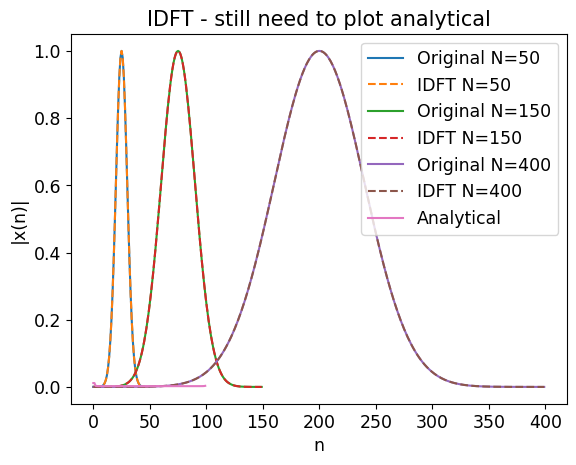

In [457]:
for N in [50, 150, 400]:
    x = func_sampled(N) #original fn
    X = DFT(x, N) #forward fourier
    x_idft = IDFT(X, N) #inverse

    n = np.arange(N) #the n's to plot against

    plt.plot(n, x, label=f"Original N={N}")
    plt.plot(n, x_idft, '--', label=f"IDFT N={N}")


N=100
k_a = 2*np.pi * np.arange(N)/N
n_i = func_analytic(k_a)
n = np.arange(N)
x_idft = IDFT(n_i, N)
plt.plot(n,x_idft,label="Analytical")


plt.legend()
plt.title("IDFT - still need to plot analytical")
plt.xlabel("n")
plt.ylabel("|x(n)|")
plt.show()

# Q1 c

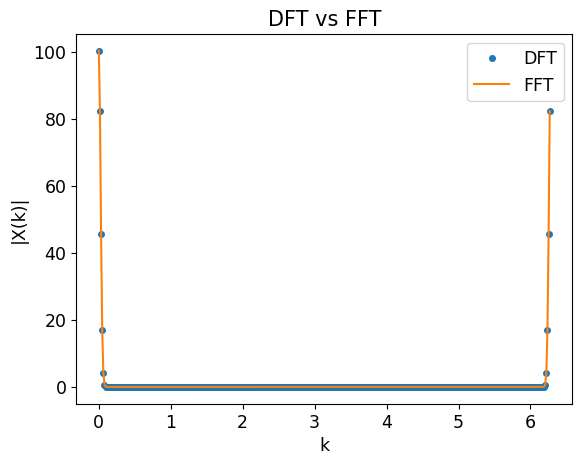

In [464]:
N = 400  
x = func_sampled(N) #discretizing function given

X_dft = DFT(x, N) #my DFT
X_fft = fft(x) #Scipy fft
k = 2*np.pi * np.arange(N)/N #k vals/frequency vals to plot against

plt.plot(k, np.abs(X_dft), 'o', label="DFT", markersize=4)
plt.plot(k, np.abs(X_fft), '-', label="FFT")
plt.xlabel("k")
plt.ylabel("|X(k)|")
plt.legend()
plt.title("DFT vs FFT")
plt.savefig("DFT_FFT.png",dpi=300)
plt.show()

In [391]:
#timing stuff
Ns_dft = [2**j for j in range(3, 12)]
dft_times = []

for N in Ns_dft:
    t_total = 0.0

    for _ in range(100):
        x = func_sampled(N)

        start = time.time()
        DFT(x, N)
        end = time.time()

        t_total += (end - start)

    dft_times.append(t_total / 100)

In [392]:
Ns_fft = [2**j for j in range(3, 21)]
fft_times = []

for N in Ns_fft:
    t_total = 0.0

    for _ in range(100):
        x = func_sampled(N)

        start = time.time()
        fft(x)
        end = time.time()

        t_total += (end - start)

    fft_times.append(t_total / 100)

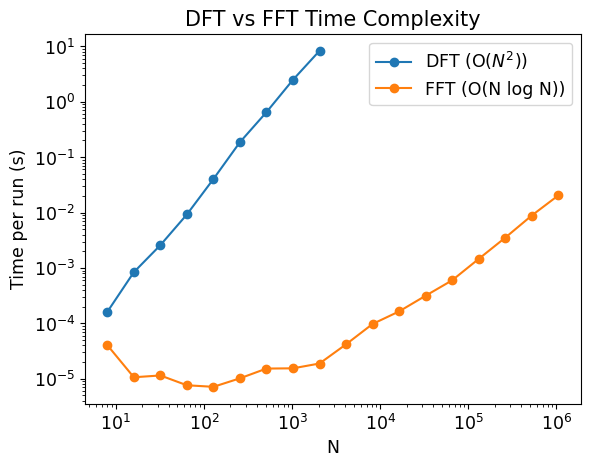

In [465]:
plt.figure()

plt.loglog(Ns_dft, dft_times, 'o-', label=r"DFT (O($N^{2}$))")
plt.loglog(Ns_fft, fft_times, 'o-', label="FFT (O(N log N))")

plt.xlabel("N")
plt.ylabel("Time per run (s)")
plt.title("DFT vs FFT Time Complexity")
plt.legend()
plt.savefig("Time_Complexity.png",dpi=300)
plt.show()

# Q2 a

In [479]:
def heat(N):
    x = np.arange(N)/N 
    return np.exp(-50*(x-0.5)**2)

In [480]:
def heat_ode(a,k,uhat):
    return -a*k**2*uhat
    
def RK4_heat(k, u0, alpha, dt, T):
    steps = int(T/dt)

    u = u0.copy()
    k_vals = np.zeros((steps, len(k)), dtype=complex)

    for i in range(steps):
        t = i*dt

        k1 = heat_ode(alpha, k, u)
        k2 = heat_ode(alpha, k, u + 0.5*dt*k1)
        k3 = heat_ode(alpha, k, u + 0.5*dt*k2)
        k4 = heat_ode(alpha, k, u + dt*k3)

        u = u + (dt/6)*(k1 + 2*k2 + 2*k3 + k4)

        k_vals[i] = u

    return k_vals

In [481]:
N = 100
u0 = heat(N) #og heat eqn
u0_k = DFT(u0, N) #forward fourier
k = 2*np.pi * np.arange(N)/N #vals to plot against (should be in k space)

#other params
alpha = 0.005
dt = 0.001
T = 5

uk_t = RK4_heat(k, u0_k, alpha, dt, T) #RK solve in k-space
ux_t = np.zeros_like(uk_t, dtype=float) #same shape and size as uk_t

#need a loop for discrete values for IDFT
for t in range(len(uk_t)): 
    ux_t[t] = np.real(IDFT(uk_t[t], N))

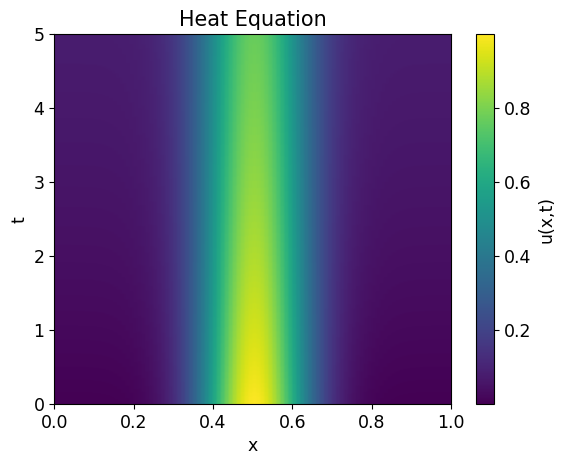

In [482]:
plt.imshow(ux_t,aspect='auto',origin='lower',extent=[0, 1, 0, T])
plt.colorbar(label="u(x,t)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Heat Equation")
plt.savefig("Heat_Eqn.png",dpi=300)
plt.show()

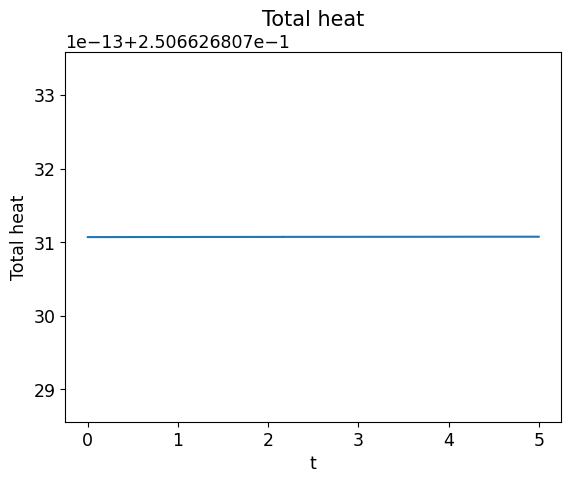

In [487]:
total_heat = np.sum(ux_t, axis=1) / N

plt.plot(np.linspace(0,T,len(total_heat)), total_heat)
plt.xlabel("t")
plt.ylabel("Total heat")
plt.title("Total heat")
plt.savefig("Total_heat.png",dpi=300)
plt.show()

# Q2 b

In [485]:
alpha = 0.05
dt = 0.01
T = 5

uk_t2 = RK4_heat(k, u0_k, alpha, dt, T) #RK solve in k-space
ux_t2 = np.zeros_like(uk_t2, dtype=float) #IDFT

for t in range(len(uk_t2)): #need a loop for discrete values
    ux_t2[t] = np.real(IDFT(uk_t2[t], N))

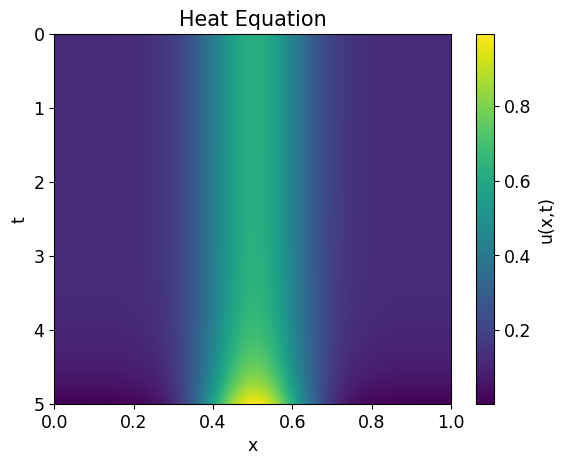

In [486]:
plt.imshow(ux_t2,aspect='auto',extent=[0,1,T,0],origin='lower')
plt.colorbar(label="u(x,t)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Heat Equation")
plt.show()